In [1]:
import pandas as pd
df = pd.read_csv('df.csv')
df.head()

,Unnamed: 0,Date,runoff_value,Station_Type,Value,Station,Type,Latitude,Longitude,Elevation
0,0,1980-01-02,118.0,601_ppt,0.0,601,ppt,28.783333,83.716667,2744
1,1,1980-01-03,114.0,601_ppt,0.0,601,ppt,28.783333,83.716667,2744
2,2,1980-01-04,111.0,601_ppt,0.0,601,ppt,28.783333,83.716667,2744
3,3,1980-01-05,111.0,601_ppt,0.0,601,ppt,28.783333,83.716667,2744
4,4,1980-01-06,108.0,601_ppt,0.0,601,ppt,28.783333,83.716667,2744


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 467488 entries, 0 to 467487
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Unnamed: 0    467488 non-null  int64  
 1   Date          467488 non-null  object 
 2   runoff_value  467488 non-null  float64
 3   Station_Type  467488 non-null  object 
 4   Value         467488 non-null  float64
 5   Station       467488 non-null  int64  
 6   Type          467488 non-null  object 
 7   Latitude      467488 non-null  float64
 8   Longitude     467488 non-null  float64
 9   Elevation     467488 non-null  int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 35.7+ MB


Runoff and Precipitation Time Series Plot

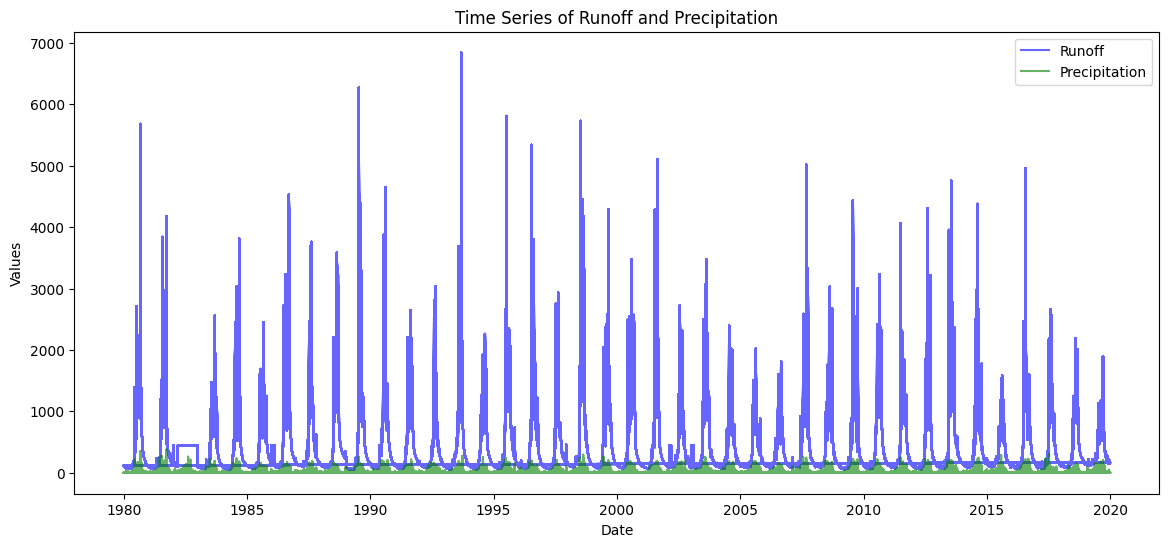

In [3]:
import matplotlib.pyplot as plt

# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Separate the runoff and precipitation data
runoff_df = df[['Date', 'runoff_value']].dropna()
precipitation_df = df[df['Type'] == 'ppt'][['Date', 'Value']].dropna()

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(runoff_df['Date'], runoff_df['runoff_value'], label='Runoff', color='blue', alpha=0.6)
plt.plot(precipitation_df['Date'], precipitation_df['Value'], label='Precipitation', color='green', alpha=0.6)
plt.xlabel('Date')
plt.ylabel('Values')
plt.title('Time Series of Runoff and Precipitation')
plt.legend()
plt.show()

Rolling Average Plot

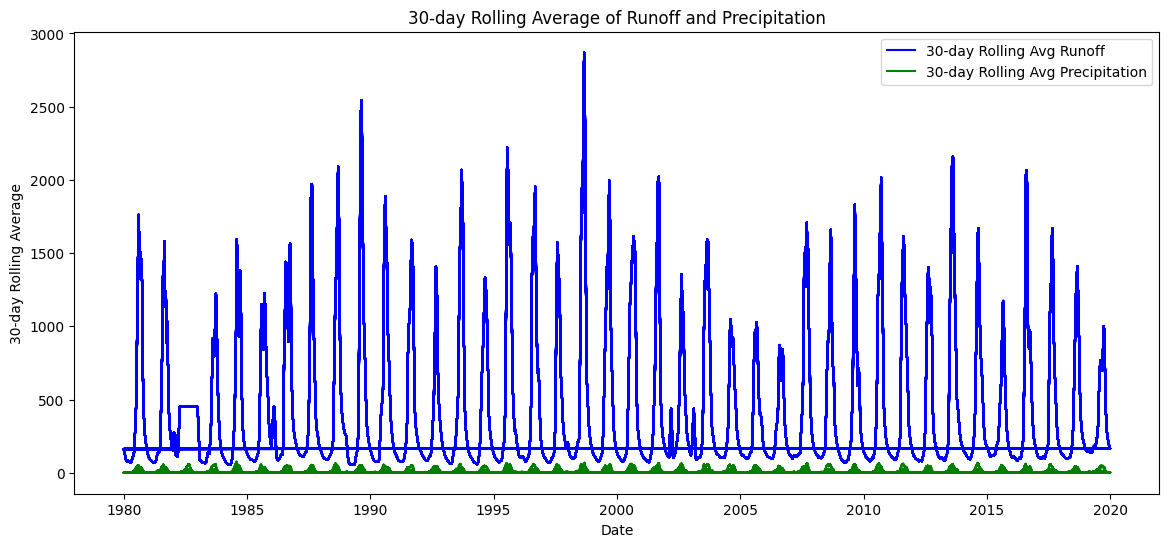

In [4]:
# Calculate 30-day rolling averages
runoff_df['Runoff_RollingMean'] = runoff_df['runoff_value'].rolling(window=30).mean()
precipitation_df['Precip_RollingMean'] = precipitation_df['Value'].rolling(window=30).mean()

# Plotting rolling averages
plt.figure(figsize=(14, 6))
plt.plot(runoff_df['Date'], runoff_df['Runoff_RollingMean'], label='30-day Rolling Avg Runoff', color='blue')
plt.plot(precipitation_df['Date'], precipitation_df['Precip_RollingMean'], label='30-day Rolling Avg Precipitation', color='green')
plt.xlabel('Date')
plt.ylabel('30-day Rolling Average')
plt.title('30-day Rolling Average of Runoff and Precipitation')
plt.legend()
plt.show()

Monthly and Annual Averages

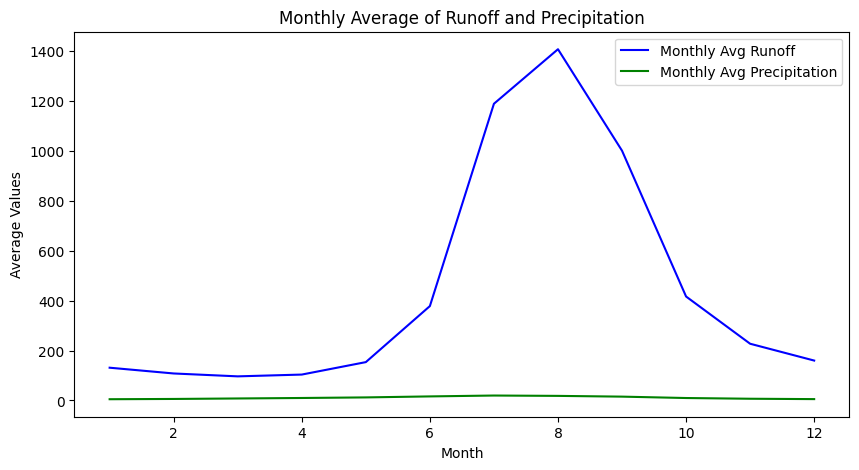

In [5]:
# Extract year and month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Calculate monthly averages
monthly_avg = df.groupby('Month').agg({'runoff_value': 'mean', 'Value': 'mean'}).reset_index()

# Plotting monthly averages
plt.figure(figsize=(10, 5))
plt.plot(monthly_avg['Month'], monthly_avg['runoff_value'], label='Monthly Avg Runoff', color='blue')
plt.plot(monthly_avg['Month'], monthly_avg['Value'], label='Monthly Avg Precipitation', color='green')
plt.xlabel('Month')
plt.ylabel('Average Values')
plt.title('Monthly Average of Runoff and Precipitation')
plt.legend()
plt.show()


Lagged Correlation Analysis

In [6]:
# Example of creating lagged values for precipitation
df['Precip_Lag1'] = df['Value'].shift(1)
df['Precip_Lag7'] = df['Value'].shift(7)
df['Precip_Lag30'] = df['Value'].shift(30)

# Calculate correlations with runoff
lagged_corrs = {
    'Lag 1': df['runoff_value'].corr(df['Precip_Lag1']),
    'Lag 7': df['runoff_value'].corr(df['Precip_Lag7']),
    'Lag 30': df['runoff_value'].corr(df['Precip_Lag30']),
}

# Display results
print("Lagged Correlations with Runoff:", lagged_corrs)


Lagged Correlations with Runoff: {'Lag 1': np.float64(0.30341979311569), 'Lag 7': np.float64(0.2641508495052651), 'Lag 30': np.float64(0.2592262038327687)}


Quarterly (3-Month Interval) Average Runoff Values Over Time

C:\Users\Gunjan M\AppData\Local\Temp\ipykernel_4348\133832001.py:8: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_runoff = df['runoff_value'].resample('Q').mean()


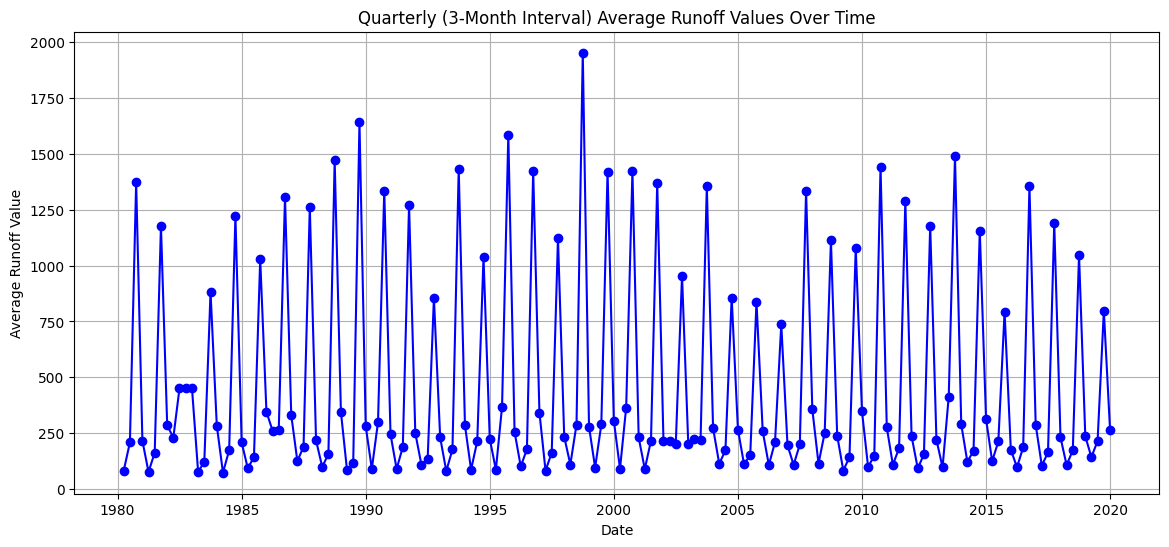

In [7]:
# Convert Date to datetime if not already done
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index for resampling
df.set_index('Date', inplace=True)

# Resample runoff values every 3 months (quarterly) and calculate mean
quarterly_runoff = df['runoff_value'].resample('Q').mean()

# Plotting the quarterly runoff values
plt.figure(figsize=(14, 6))
plt.plot(quarterly_runoff.index, quarterly_runoff.values, marker='o', color='blue', linestyle='-', linewidth=1.5)
plt.xlabel('Date')
plt.ylabel('Average Runoff Value')
plt.title('Quarterly (3-Month Interval) Average Runoff Values Over Time')
plt.grid(True)
plt.show()

Annual Averages and Anomalies

C:\Users\Gunjan M\AppData\Local\Temp\ipykernel_4348\2796486767.py:13: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_avg = df['runoff_value'].resample('Y').mean()


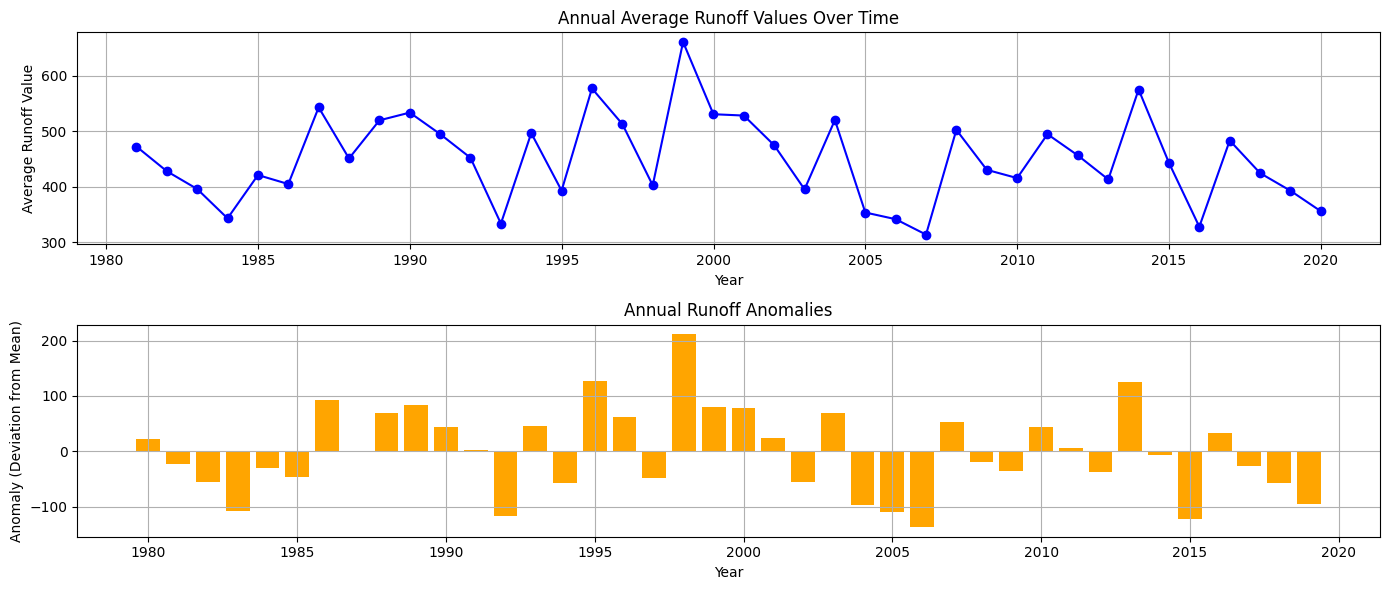

In [10]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('df.csv')
# Convert Date to datetime if not already done
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index for resampling
df.set_index('Date', inplace=True)

# Calculate annual averages
annual_avg = df['runoff_value'].resample('Y').mean()

# Calculate annual anomalies (deviation from the mean of all years)
annual_anomalies = annual_avg - annual_avg.mean()

# Plotting the annual average and anomaly
plt.figure(figsize=(14, 6))

# Plot Annual Average
plt.subplot(2, 1, 1)
plt.plot(annual_avg.index, annual_avg.values, marker='o', color='blue', linestyle='-', linewidth=1.5)
plt.xlabel('Year')
plt.ylabel('Average Runoff Value')
plt.title('Annual Average Runoff Values Over Time')
plt.grid(True)

# Plot Annual Anomalies
plt.subplot(2, 1, 2)
plt.bar(annual_anomalies.index.year, annual_anomalies.values, color='orange', width=0.8)
plt.xlabel('Year')
plt.ylabel('Anomaly (Deviation from Mean)')
plt.title('Annual Runoff Anomalies')
plt.grid(True)

plt.tight_layout()
plt.show()


Monthly average and Anomalies

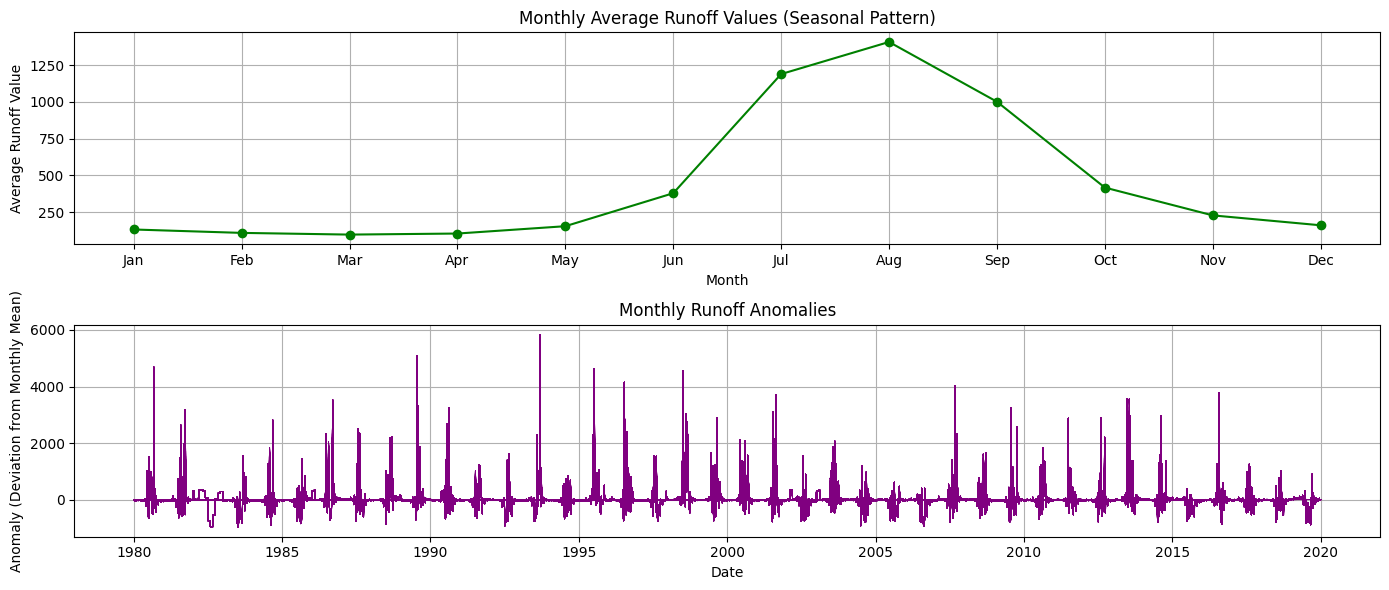

In [11]:
# Calculate monthly averages (over all years)
monthly_avg = df['runoff_value'].groupby(df.index.month).mean()

# Calculate monthly anomalies (deviation from monthly average)
monthly_anomalies = df['runoff_value'] - df['runoff_value'].groupby(df.index.month).transform('mean')

# Plotting the monthly average
plt.figure(figsize=(14, 6))

# Plot Monthly Average
plt.subplot(2, 1, 1)
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', color='green', linestyle='-', linewidth=1.5)
plt.xlabel('Month')
plt.ylabel('Average Runoff Value')
plt.title('Monthly Average Runoff Values (Seasonal Pattern)')
plt.grid(True)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Plot Monthly Anomalies
plt.subplot(2, 1, 2)
plt.plot(df.index, monthly_anomalies, color='purple', linestyle='-', linewidth=0.7)
plt.xlabel('Date')
plt.ylabel('Anomaly (Deviation from Monthly Mean)')
plt.title('Monthly Runoff Anomalies')
plt.grid(True)

plt.tight_layout()
plt.show()


Correlation Heatmap

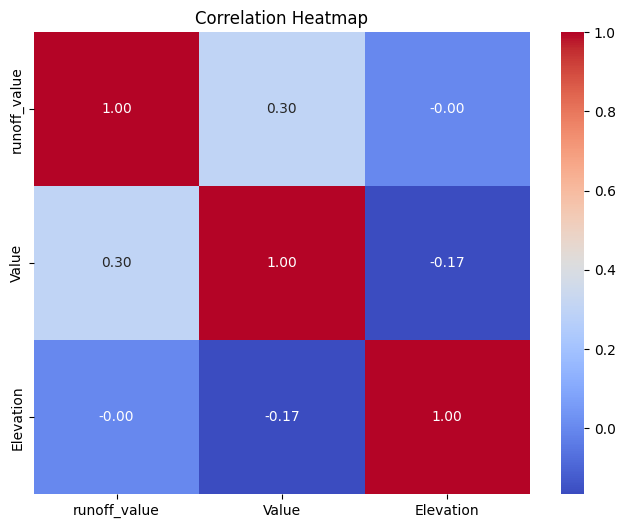

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
corr_matrix = df[['runoff_value', 'Value', 'Elevation']].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


Elevation vs. Runoff and Precipitation Scatter Plot

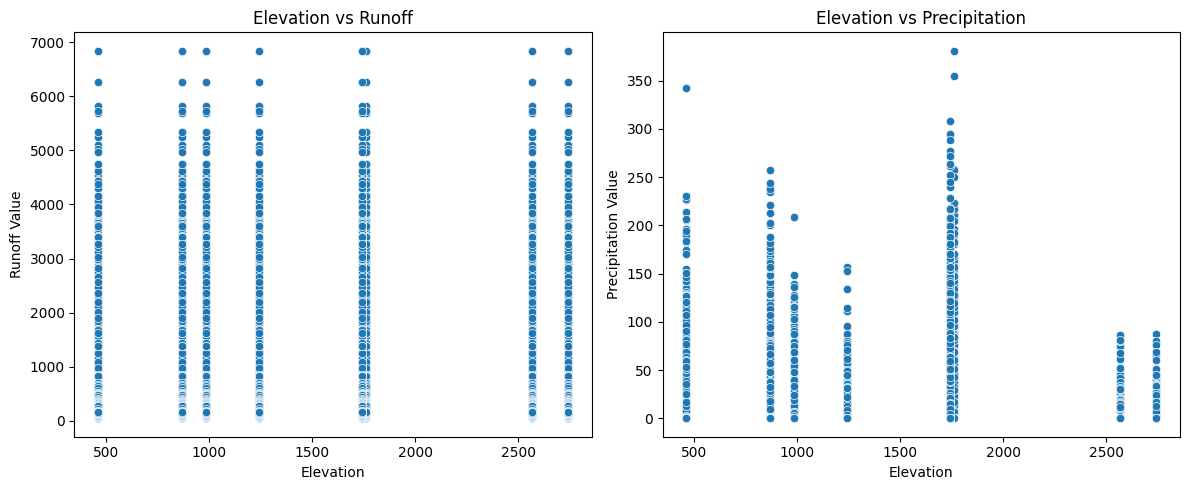

In [13]:
# Scatter plot for Elevation vs Runoff
plt.figure(figsize=(12, 5))

# Elevation vs Runoff
plt.subplot(1, 2, 1)
sns.scatterplot(x='Elevation', y='runoff_value', data=df)
plt.title("Elevation vs Runoff")
plt.xlabel("Elevation")
plt.ylabel("Runoff Value")

# Elevation vs Precipitation
plt.subplot(1, 2, 2)
sns.scatterplot(x='Elevation', y='Value', data=df[df['Type'] == 'ppt'])  # filter for precipitation data
plt.title("Elevation vs Precipitation")
plt.xlabel("Elevation")
plt.ylabel("Precipitation Value")

plt.tight_layout()
plt.show()


Histogram and Density Plots for Distribution Analysis

C:\Users\Gunjan M\AppData\Local\Temp\ipykernel_4348\2492008168.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['runoff_value'], shade=True)


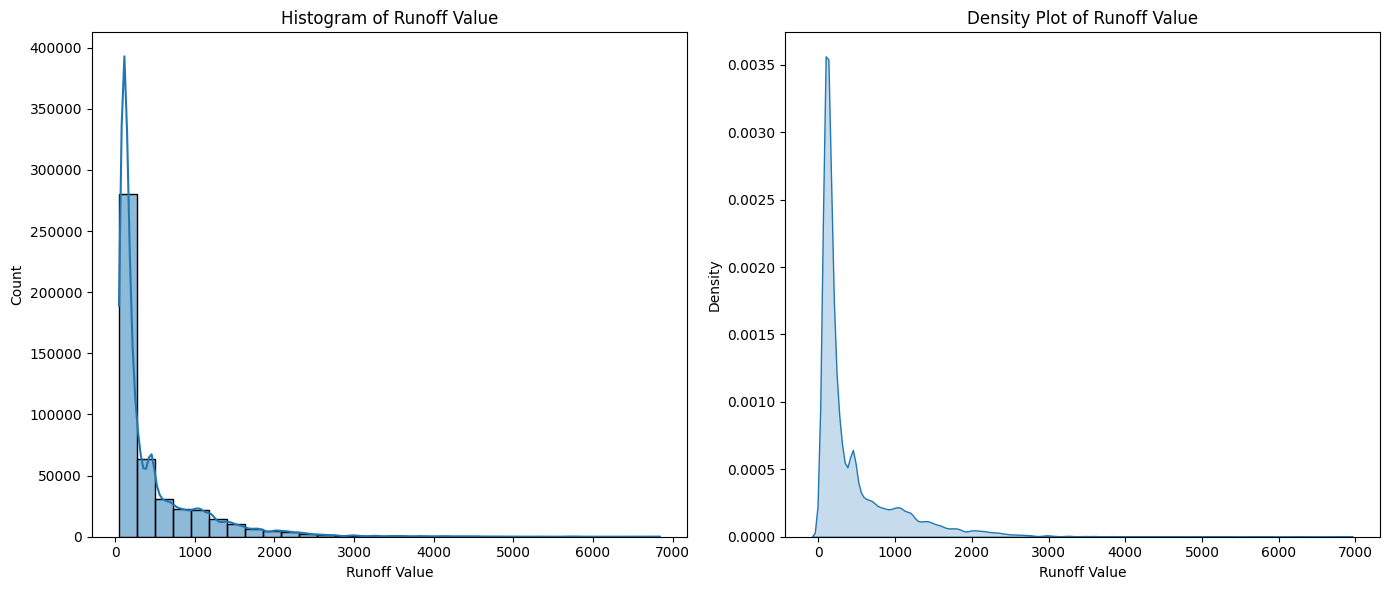

C:\Users\Gunjan M\AppData\Local\Temp\ipykernel_4348\2492008168.py:26: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Type'] == 'ppt']['Value'], shade=True)


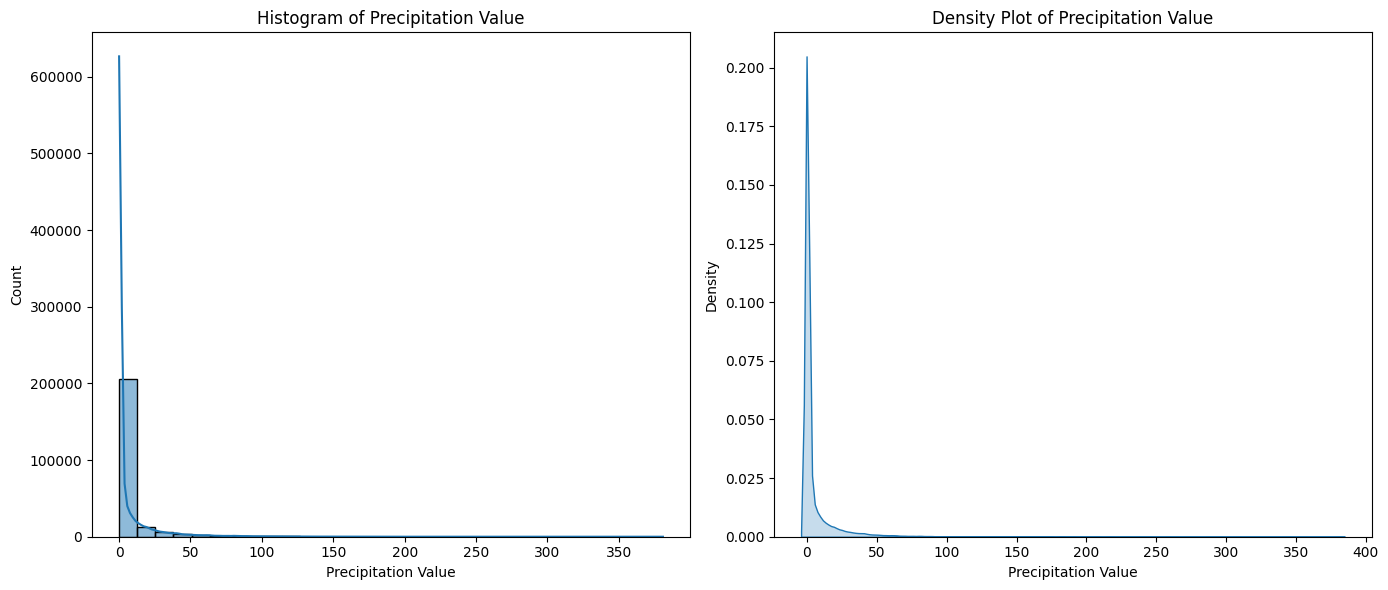

In [14]:
# Histogram and Density Plot for Runoff
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['runoff_value'], bins=30, kde=True)
plt.title("Histogram of Runoff Value")
plt.xlabel("Runoff Value")

plt.subplot(1, 2, 2)
sns.kdeplot(df['runoff_value'], shade=True)
plt.title("Density Plot of Runoff Value")
plt.xlabel("Runoff Value")

plt.tight_layout()
plt.show()

# Histogram and Density Plot for Precipitation (filter for precipitation data)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[df['Type'] == 'ppt']['Value'], bins=30, kde=True)
plt.title("Histogram of Precipitation Value")
plt.xlabel("Precipitation Value")

plt.subplot(1, 2, 2)
sns.kdeplot(df[df['Type'] == 'ppt']['Value'], shade=True)
plt.title("Density Plot of Precipitation Value")
plt.xlabel("Precipitation Value")

plt.tight_layout()
plt.show()


Extreme Value Analysis

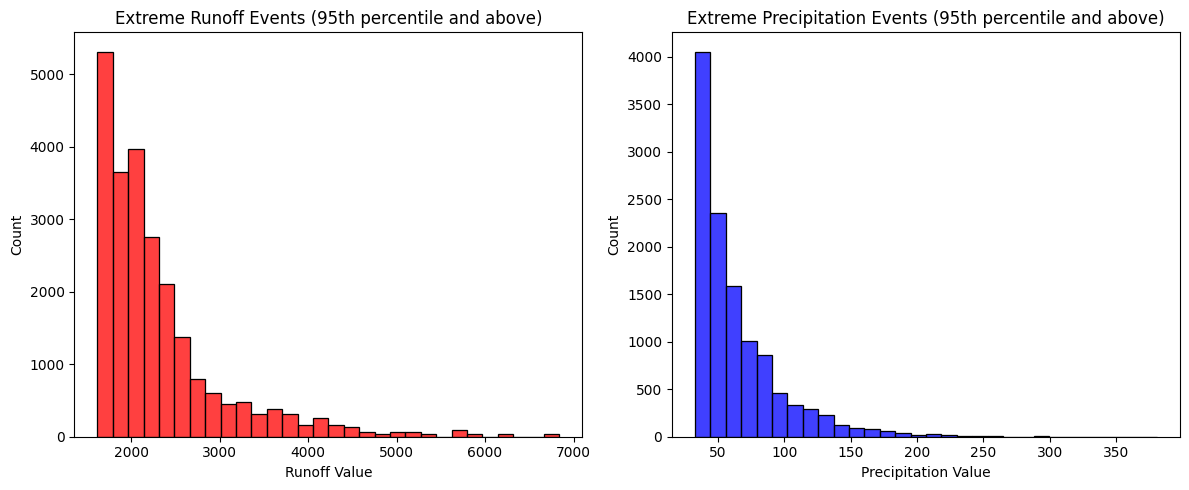

In [15]:
# Define thresholds for extreme values
runoff_threshold = df['runoff_value'].quantile(0.95)  # 95th percentile for runoff
precip_threshold = df[df['Type'] == 'ppt']['Value'].quantile(0.95)  # 95th percentile for precipitation

# Plot extreme runoff events
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[df['runoff_value'] >= runoff_threshold]['runoff_value'], bins=30, color="red")
plt.title("Extreme Runoff Events (95th percentile and above)")
plt.xlabel("Runoff Value")

# Plot extreme precipitation events
plt.subplot(1, 2, 2)
sns.histplot(df[(df['Type'] == 'ppt') & (df['Value'] >= precip_threshold)]['Value'], bins=30, color="blue")
plt.title("Extreme Precipitation Events (95th percentile and above)")
plt.xlabel("Precipitation Value")

plt.tight_layout()
plt.show()


Machine Learning

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Load data
df['Date'] = pd.to_datetime(df['Date'])

# Temporal features
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day

# Target and features
X = df.drop(columns=['runoff_value'])
y = df['runoff_value']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


ModuleNotFoundError: No module named 'distutils'